<a href="https://colab.research.google.com/github/aman-5137/half_plasma/blob/main/_7_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A decision tree is a flowchart like model used in machine learning and decision analysis to map out decisions, data split and their respective outcomes.

In [11]:
# Splits data into smaller, manageable subsets.
import pandas as pd
df = pd.read_csv('/content/sample_data/heart_disease.csv')
df['target'] = (df['num'] > 0).astype(int)

X = df.drop(columns=['num', 'target'])
y = df['target']

# Replace '?' with NaN and convert columns to numeric, then impute missing values
X = X.replace('?', pd.NA)
X['ca'] = pd.to_numeric(X['ca'])
X['thal'] = pd.to_numeric(X['thal'])

# Impute missing values with the mean
X['ca'] = X['ca'].fillna(X['ca'].mean())
X['thal'] = X['thal'].fillna(X['thal'].mean())

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print('train :', X_train.shape[0], "test :" ,X_test.shape[0])

train : 242 test : 61


In [12]:
# Training the svm classifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC(kernel="rbf")
svm.fit(X_train_scaled, y_train)


print(classification_report(y_test, svm.predict(X_test_scaled), target_names=['no disease', 'disease']))

              precision    recall  f1-score   support

  no disease       0.90      0.79      0.84        33
     disease       0.78      0.89      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



In [17]:
print('svm- train accuracy: ', round(svm.score(X_train_scaled, y_train), 3))
print('svm- test accuracy: ', round(svm.score(X_test_scaled, y_test), 3))

svm- train accuracy:  0.905
svm- test accuracy:  0.836


In [14]:
# Train Decision tree classifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth = 3,random_state=42)
tree.fit(X_train, y_train)
report  = classification_report(y_test, tree.predict(X_test), target_names=['no disease', 'disease'])
print(report)

              precision    recall  f1-score   support

  no disease       0.88      0.85      0.86        33
     disease       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [15]:
print('Decision Tree: Train accuracy: ', round(tree.score(X_train, y_train), 3))
print('Decision Tree: Test accuracy: ', round(tree.score(X_test, y_test), 3))

Decision Tree: Train accuracy:  0.847
Decision Tree: Test accuracy:  0.852


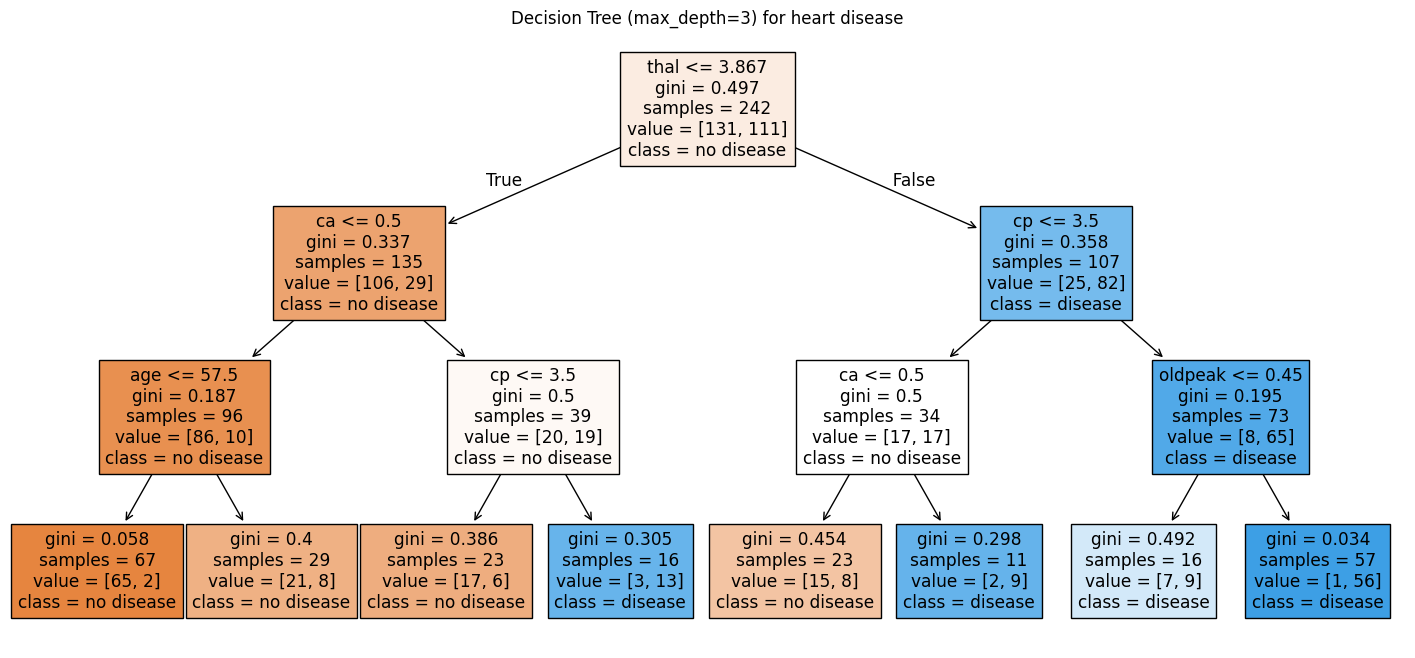

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize = (18, 8))
plot_tree(tree, filled = True, feature_names = X.columns, class_names = ['no disease', 'disease'])
plt.title('Decision Tree (max_depth=3) for heart disease')
plt.show()

In [20]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target'],
      dtype='object')

In [21]:
tree.feature_importances_

array([0.03634015, 0.        , 0.19007404, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.06536644,
       0.        , 0.16953831, 0.53868106])

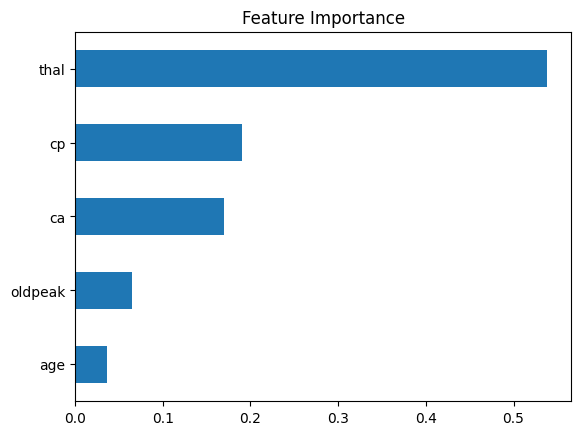

In [23]:
importance = pd.Series(tree.feature_importances_, index=X.columns)
importance = importance[importance > 0].sort_values()

importance.plot(kind ='barh')
plt.title('Feature Importance')
plt.show()
#